C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9580 - loss: 0.1393 - val_accuracy: 0.9807 - val_loss: 0.0561
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9862 - loss: 0.0449 - val_accuracy: 0.9856 - val_loss: 0.0457
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9899 - loss: 0.0318 - val_accuracy: 0.9881 - val_loss: 0.0370
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9927 - loss: 0.0237 - val_accuracy: 0.9896 - val_loss: 0.0320
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.9890 - val_loss: 0.0346

Evaluating...
Test Accuracy: 0.9890
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


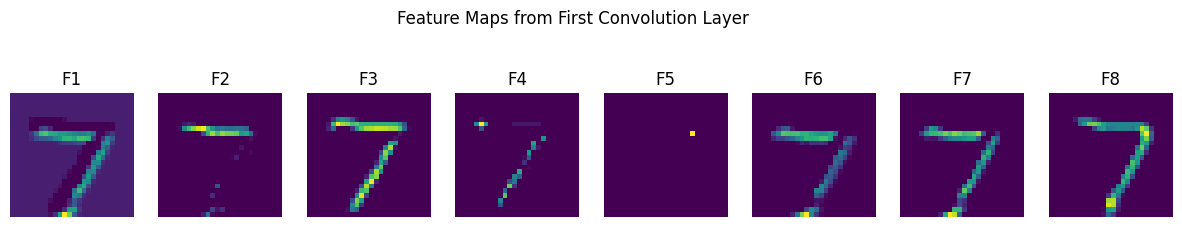

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import layers
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# CNN Model
model = keras.Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
print("\nStarting Training...")
model.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test, y_test))

# Evaluate model
print("\nEvaluating...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Create activation model for Conv2D layers
layer_outputs = [
    layer.output for layer in model.layers
    if isinstance(layer, layers.Conv2D)
]
activation_model = keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)
# Select a test image
img = X_test[0].reshape(1, 28, 28, 1)

# Predict activations
activations = activation_model.predict(img)

# Visualize first Conv layer feature maps
first_layer_activations = activations[0]

num_filters = 8
fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))

for i in range(num_filters):
    axes[i].imshow(
        first_layer_activations[0, :, :, i],
        cmap='viridis'
    )
    axes[i].axis('off')
    axes[i].set_title(f'F{i+1}')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()